<a href="https://colab.research.google.com/github/Nazif-25/heart-disease-analysis-and-prediction/blob/main/heart_disease_analysis_and_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, silhouette_score

# Machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
import gdown

url = "https://drive.google.com/uc?id=1dIRt6MlvmbSGH8hmQnFd0tsUfwoAXCgr"
output = "heart_disease.csv"

gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1dIRt6MlvmbSGH8hmQnFd0tsUfwoAXCgr
To: /content/heart_disease.csv
100%|██████████| 79.3k/79.3k [00:00<00:00, 71.8MB/s]


'heart_disease.csv'

In [3]:
df = pd.read_csv("heart_disease.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
#1 Number of features
# we are excluding the num and id columns as they are not features
num_features = df.shape[1] - 2
print(f"Number of features: {num_features}")

Number of features: 14


In [6]:
#2:Type of problem
target = df.columns[-1]

unique_values = df[target].nunique()

print("Unique values:", unique_values)

if unique_values <= 20:
    problem_type = "Classification"
else:
    problem_type = "Regression"

print(f"Problem type: {problem_type}")

Unique values: 5
Problem type: Classification


In [7]:
# numerical data:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='object')

In [8]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [9]:
# categorical data:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [10]:
df[categorical_cols].describe().T

,count,unique,top,freq
sex,920,2,Male,726
dataset,920,4,Cleveland,304
cp,920,4,asymptomatic,496
fbs,830,2,False,692
restecg,918,3,normal,551
exang,865,2,False,528
slope,611,3,flat,345
thal,434,3,normal,196


EDA

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


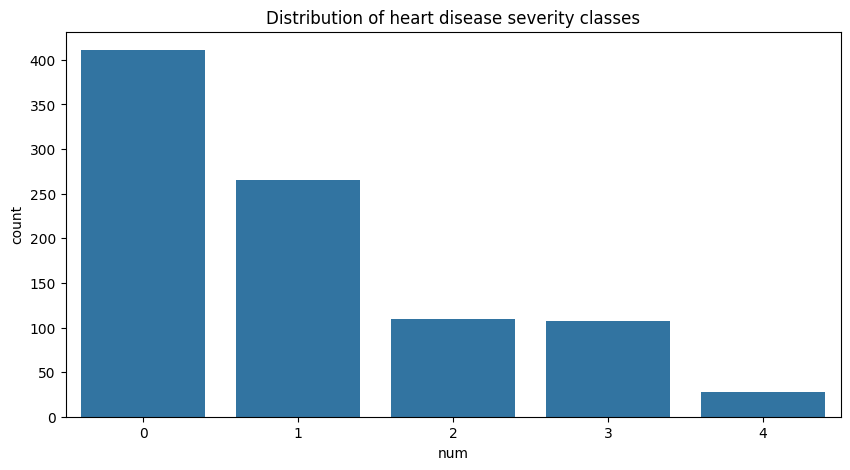

In [11]:
target_col = "num"
print(df[target_col].value_counts())
"""
The above tells us how many rows have n level classification
"""

plt.figure(figsize=(10,5))
sns.countplot(x=target_col, data=df)
plt.title("Distribution of heart disease severity classes")
plt.show()

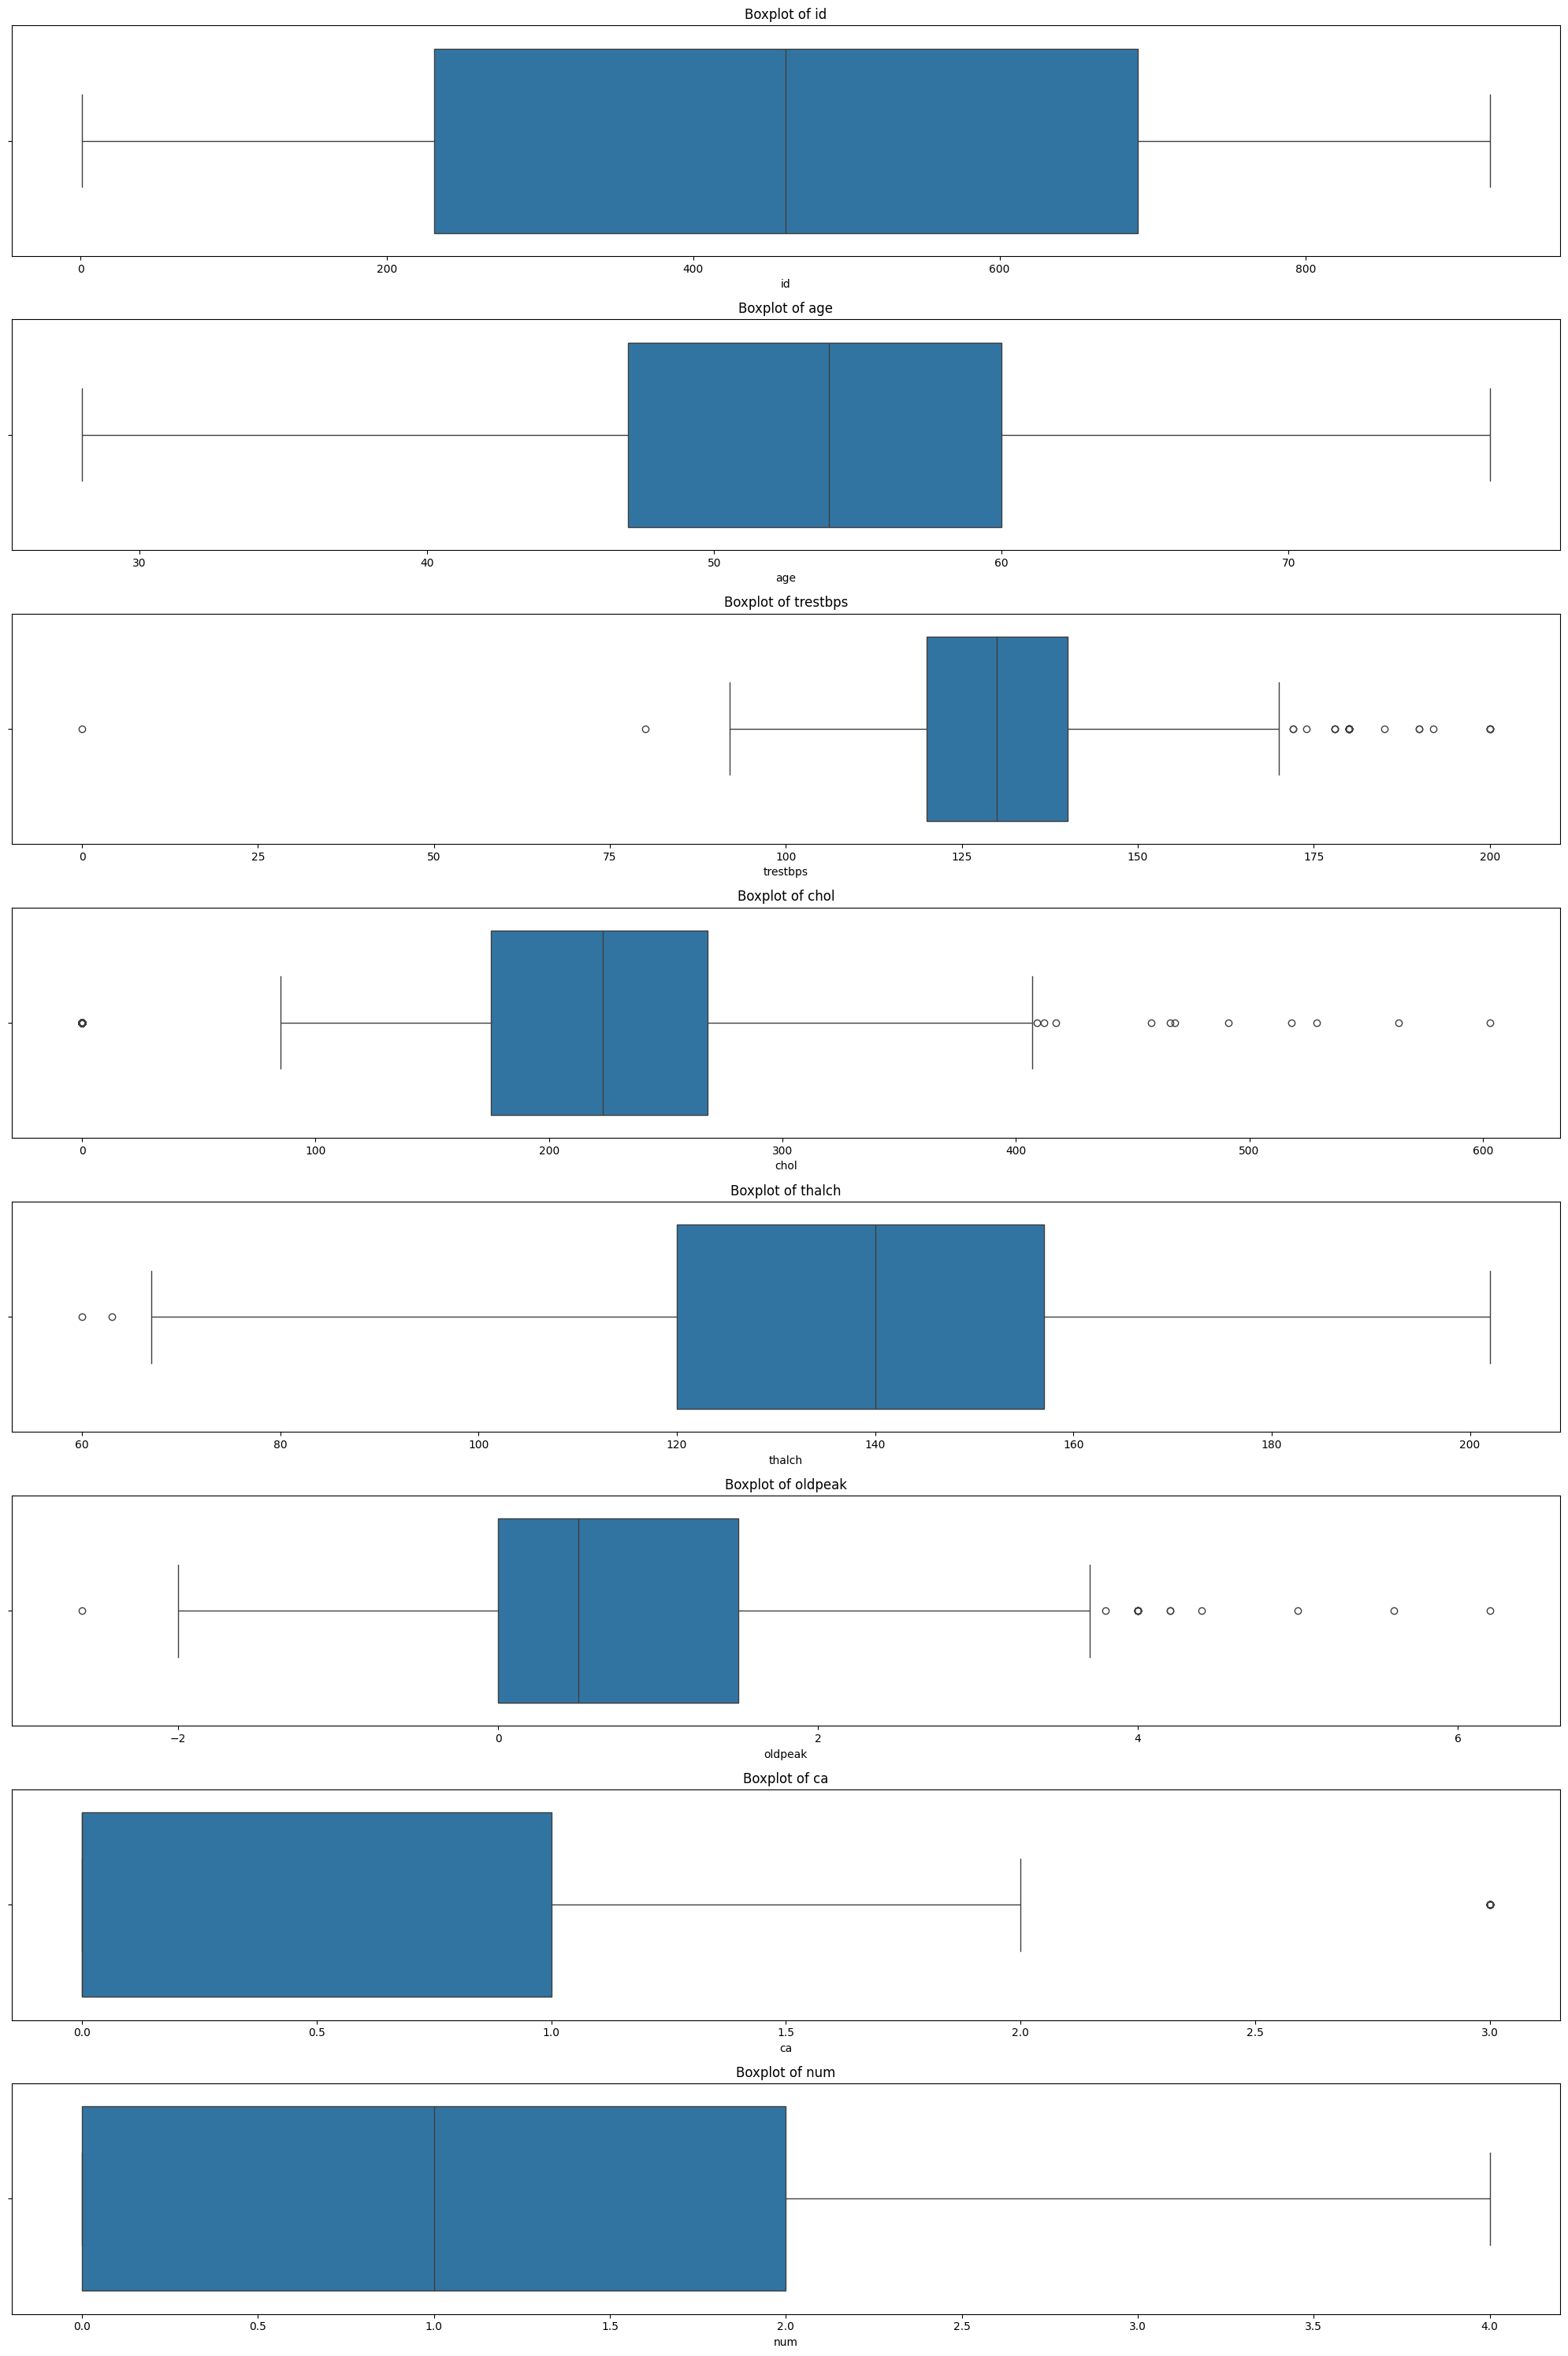

In [ ]:
# Box plots for numerical data
plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.tight_layout()
plt.show()

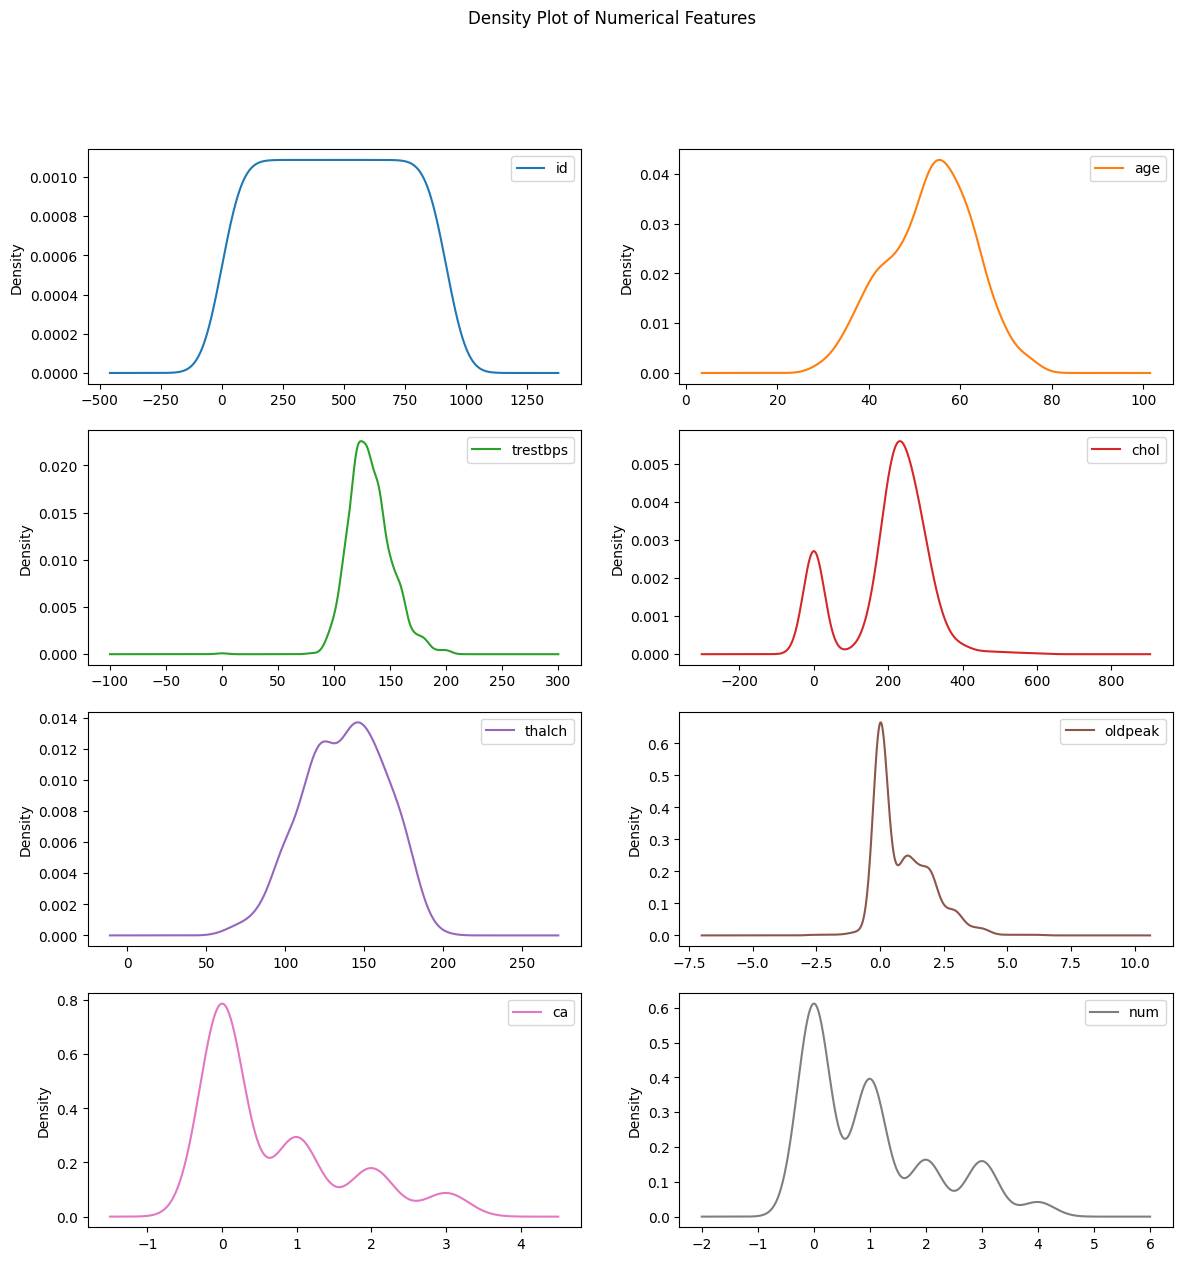

In [ ]:
# Density graph for numerical data
df[numerical_cols].plot(kind="density", figsize=(14,14), subplots=True, layout=(4,2), title="Density Plot of Numerical Features", sharex=False)
plt.show()

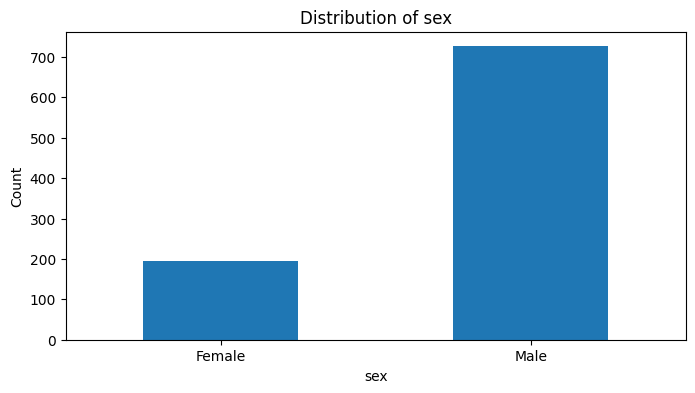

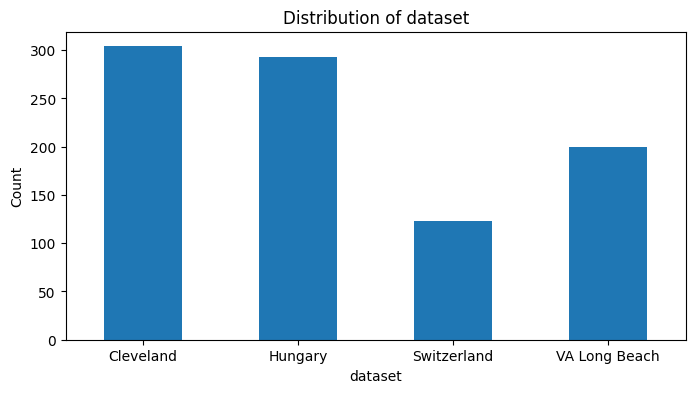

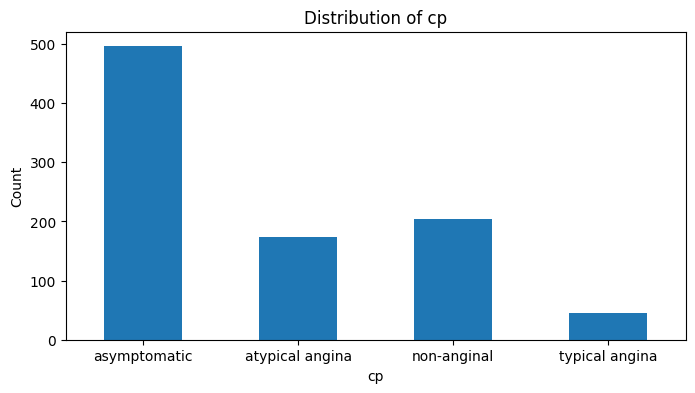

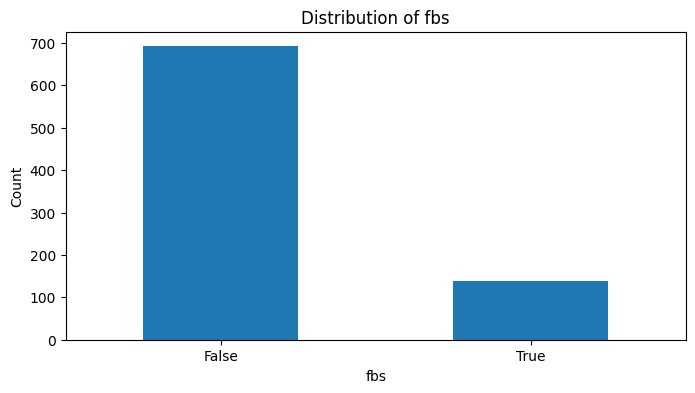

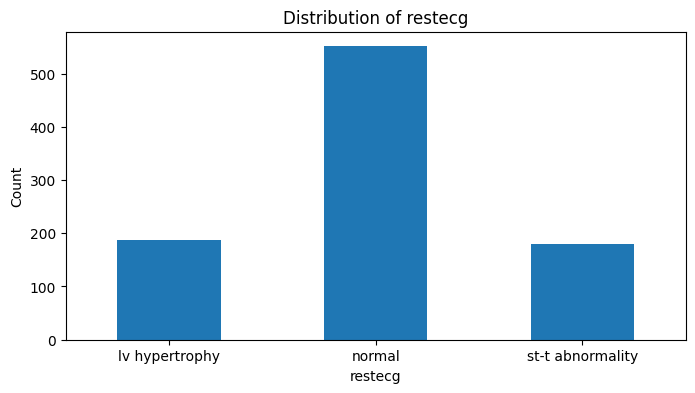

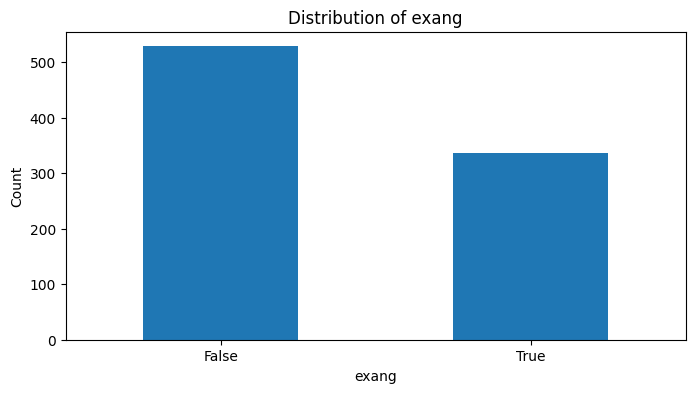

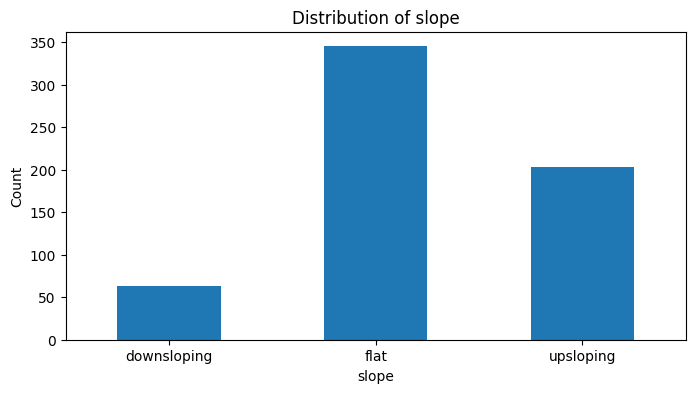

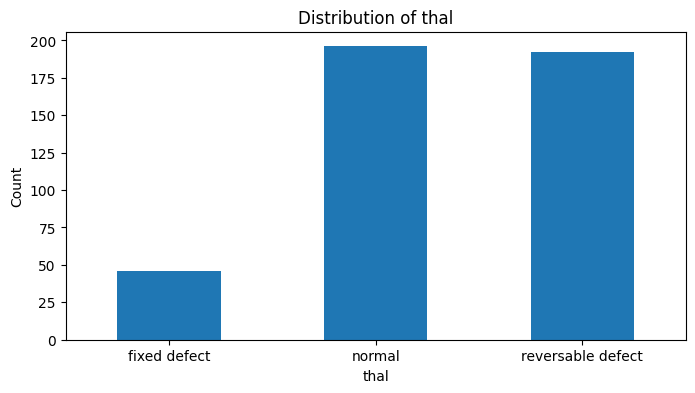

In [ ]:
# Bar graphs for categorical data
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().sort_index().plot(kind="bar", rot=0)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Data Preprocessing and Feature Encoding

In [ ]:
# Check null values
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


imputing.

null values in categorical cols imputed with mode.

null values in numerical cols imputed with median


In [ ]:
# Handle null values if any
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Convert boolean-like columns to 1/0
df['fbs'] = df['fbs'].map({True: 1, False: 0})
df['exang'] = df['exang'].map({True: 1, False: 0})

df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [ ]:
# Handle duplicate values
print("Number of duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Number of duplicate rows before: 0
Number of duplicate rows after: 0
New dataset shape: (920, 16)


Feature encoding

In [ ]:
# Label encoding for categorical columns
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0
5,6,56,1,0,1,120.0,236.0,0,1,178.0,0,0.8,2,0.0,1,0
6,7,62,0,0,0,140.0,268.0,0,0,160.0,0,3.6,0,2.0,1,3
7,8,57,0,0,0,120.0,354.0,0,1,163.0,1,0.6,2,0.0,1,0
8,9,63,1,0,0,130.0,254.0,0,0,147.0,0,1.4,1,1.0,2,2
9,10,53,1,0,0,140.0,203.0,1,0,155.0,1,3.1,0,0.0,2,1


In [ ]:
# Correlation matrix
df.corr()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,1.000000,0.239301,0.280053,0.949062,-0.189430,0.039382,-0.370721,0.148983,0.479012,-0.428727,0.166239,0.014034,-0.305000,-0.385881,-0.169764,0.273552
age,0.239301,1.000000,0.056889,0.235076,-0.076519,0.230784,-0.086010,0.219915,-0.006652,-0.349715,0.160910,0.233550,-0.077087,0.219413,0.101109,0.339596
sex,0.280053,0.056889,1.000000,0.285734,-0.125933,-0.002145,-0.194029,0.075370,0.072160,-0.174590,0.155204,0.090794,-0.105805,-0.037847,0.076023,0.259342
dataset,0.949062,0.235076,0.285734,1.000000,-0.150334,0.008343,-0.410777,0.170110,0.460189,-0.373492,0.129326,0.012767,-0.297152,-0.371451,-0.146806,0.276203
cp,-0.189430,-0.076519,-0.125933,-0.150334,1.000000,-0.023980,0.065089,0.006370,-0.070150,0.290613,-0.360513,-0.177489,0.113415,-0.046250,-0.097099,-0.314518
trestbps,0.039382,0.230784,-0.002145,0.008343,-0.023980,1.000000,0.089484,0.143709,0.010263,-0.104747,0.153835,0.161217,-0.050446,0.039092,0.066675,0.113178
chol,-0.370721,-0.086010,-0.194029,-0.410777,0.065089,0.089484,1.000000,0.089316,-0.199594,0.226047,-0.033914,0.047454,0.033221,0.152514,-0.052708,-0.230539
fbs,0.148983,0.219915,0.075370,0.170110,0.006370,0.143709,0.089316,1.000000,0.025788,-0.026472,-0.003475,0.034112,-0.070830,0.061260,-0.005670,0.129539
restecg,0.479012,-0.006652,0.072160,0.460189,-0.070150,0.010263,-0.199594,0.025788,1.000000,-0.161818,0.026067,-0.047235,-0.128925,-0.306549,-0.169442,0.034603
thalch,-0.428727,-0.349715,-0.174590,-0.373492,0.290613,-0.104747,0.226047,-0.026472,-0.161818,1.000000,-0.354173,-0.149401,0.289251,0.038207,-0.054336,-0.349173


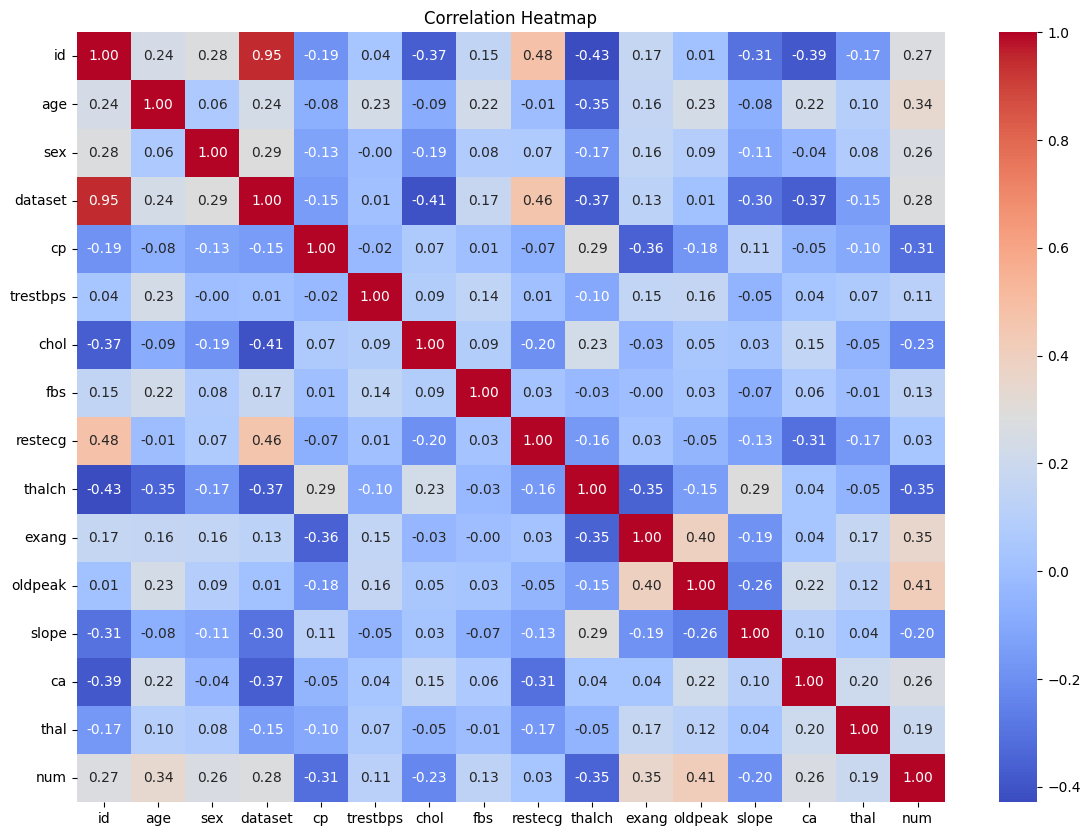

In [ ]:
# Heatmap for correlation
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
"""
we drop id and dataset because they are just labels and will not
help the model learn patterns
"""
df = df.drop(['id', 'dataset'], axis=1)

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0
5,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0.0,1,0
6,62,0,0,140.0,268.0,0,0,160.0,0,3.6,0,2.0,1,3
7,57,0,0,120.0,354.0,0,1,163.0,1,0.6,2,0.0,1,0
8,63,1,0,130.0,254.0,0,0,147.0,0,1.4,1,1.0,2,2
9,53,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0.0,2,1


In [ ]:
# Feature scaling
target_col = "num"
features = df.drop(target_col, axis=1)
target = df[target_col]

scaler = StandardScaler()
# we use standardscalar to normalise features with large ranges so that they don't dominate ones with small ranges
features_scaled = scaler.fit_transform(features)
# pd.dataframe converts the numpy array into a neat and organised table
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,1.007386,0.516931,2.319860,0.705176,0.303643,2.380476,-1.567991,0.489727,-0.760292,1.368109,-2.234081,-0.361400,-2.397813
1,1.432034,0.516931,-0.818774,1.518569,0.789967,-0.420084,-1.567991,-1.181478,1.315283,0.611589,-0.295067,4.411152,-0.328406
2,1.432034,0.516931,-0.818774,-0.650479,0.266939,-0.420084,-1.567991,-0.345875,1.315283,1.651804,-0.295067,2.820301,1.741001
3,-1.752828,0.516931,1.273649,-0.108217,0.459634,-0.420084,0.015491,1.961979,-0.760292,2.502889,-2.234081,-0.361400,-0.328406
4,-1.328180,-1.934494,0.227437,-0.108217,0.037541,-0.420084,-1.567991,1.365120,-0.760292,0.517024,1.643946,-0.361400,-0.328406
5,0.264251,0.516931,0.227437,-0.650479,0.331171,-0.420084,0.015491,1.603864,-0.760292,-0.050366,1.643946,-0.361400,-0.328406
6,0.901224,-1.934494,-0.818774,0.434045,0.624800,-0.420084,-1.567991,0.887633,-0.760292,2.597454,-2.234081,2.820301,-0.328406
7,0.370413,-1.934494,-0.818774,-0.650479,1.413930,-0.420084,0.015491,1.007005,1.315283,-0.239496,1.643946,-0.361400,-0.328406
8,1.007386,0.516931,-0.818774,-0.108217,0.496338,-0.420084,-1.567991,0.370355,-0.760292,0.517024,-0.295067,1.229451,1.741001
9,-0.054235,0.516931,-0.818774,0.434045,0.028366,2.380476,-1.567991,0.688680,1.315283,2.124629,-2.234081,-0.361400,1.741001


## Data splitting

In [ ]:
features_train, features_test, target_train, target_test = train_test_split(
    features_scaled, target, test_size=0.30, random_state=42, stratify=target
)

unsupervised_train, unsupervised_test = train_test_split(features_scaled, test_size=0.30, random_state=42)

print("Train shape:", features_train.shape)
print("Test shape:", features_test.shape)

Train shape: (644, 13)
Test shape: (276, 13)


In [ ]:

# Verify stratification
print("Original target distribution:")
print(target.value_counts(normalize=True))

print("\nTest target distribution:")
print(target_test.value_counts(normalize=True))

print("\nTrain target distribution:")
print(target_train.value_counts(normalize=True))

Original target distribution:
num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64

Test target distribution:
num
0    0.445652
1    0.289855
2    0.119565
3    0.115942
4    0.028986
Name: proportion, dtype: float64

Train target distribution:
num
0    0.447205
1    0.287267
2    0.118012
3    0.116460
4    0.031056
Name: proportion, dtype: float64


## Supervised Model Training and Testing

In [ ]:
# KNeighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(features_train, target_train)
target_pred_KNeighbours = knn.predict(features_test)

accuracy_KNeighbours = accuracy_score(target_test, target_pred_KNeighbours)
precision_KNeighbours = precision_score(target_test, target_pred_KNeighbours, average="weighted")
recall_KNeighbours = recall_score(target_test, target_pred_KNeighbours, average="weighted")
f1_KNeighbours = f1_score(target_test, target_pred_KNeighbours, average="weighted")

print("Accuracy:", accuracy_KNeighbours, "Precision:", precision_KNeighbours, "Recall:", recall_KNeighbours, "F1:", f1_KNeighbours)
print(classification_report(target_test, target_pred_KNeighbours))

Accuracy: 0.5833333333333334 Precision: 0.5275296500933683 Recall: 0.5833333333333334 F1: 0.5517875780424795
              precision    recall  f1-score   support

           0       0.75      0.87      0.80       123
           1       0.51      0.55      0.53        80
           2       0.28      0.24      0.26        33
           3       0.12      0.06      0.08        32
           4       0.00      0.00      0.00         8

    accuracy                           0.58       276
   macro avg       0.33      0.34      0.33       276
weighted avg       0.53      0.58      0.55       276



In [ ]:
# Decision Tree
dT = DecisionTreeClassifier(random_state=42)
dT.fit(features_train, target_train)
target_pred_DT = dT.predict(features_test)

accuracy_DT = accuracy_score(target_test, target_pred_DT)
precision_DT = precision_score(target_test, target_pred_DT, average="weighted")
recall_DT = recall_score(target_test, target_pred_DT, average="weighted")
f1_DT = f1_score(target_test, target_pred_DT, average="weighted")

print("Accuracy:", accuracy_DT, "Precision:", precision_DT, "Recall:", recall_DT, "F1:", f1_DT)
print(classification_report(target_test, target_pred_DT))

Accuracy: 0.5072463768115942 Precision: 0.5127216261372292 Recall: 0.5072463768115942 F1: 0.5097653950347008
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       123
           1       0.45      0.42      0.44        80
           2       0.24      0.24      0.24        33
           3       0.29      0.28      0.29        32
           4       0.08      0.12      0.10         8

    accuracy                           0.51       276
   macro avg       0.35      0.36      0.36       276
weighted avg       0.51      0.51      0.51       276



In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(features_train, target_train)
target_pred_LR = lr.predict(features_test)

accuracy_LR = accuracy_score(target_test, target_pred_LR)
precision_LR = precision_score(target_test, target_pred_LR, average="weighted")
recall_LR = recall_score(target_test, target_pred_LR, average="weighted")
f1_LR = f1_score(target_test, target_pred_LR, average="weighted")

print("Accuracy:", accuracy_LR, "Precision:", precision_LR, "Recall:", recall_LR, "F1:", f1_LR)
print(classification_report(target_test, target_pred_LR))

Accuracy: 0.5688405797101449 Precision: 0.5352310247394364 Recall: 0.5688405797101449 F1: 0.5493298868214739
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       123
           1       0.52      0.47      0.50        80
           2       0.21      0.15      0.18        33
           3       0.21      0.25      0.23        32
           4       0.00      0.00      0.00         8

    accuracy                           0.57       276
   macro avg       0.34      0.35      0.34       276
weighted avg       0.54      0.57      0.55       276



In [ ]:
# Naive Bayes
nb = GaussianNB()
nb.fit(features_train, target_train)
target_pred_NB = nb.predict(features_test)

accuracy_NB = accuracy_score(target_test, target_pred_NB)
precision_NB = precision_score(target_test, target_pred_NB, average="weighted")
recall_NB = recall_score(target_test, target_pred_NB, average="weighted")
f1_NB = f1_score(target_test, target_pred_NB, average="weighted")

print("Accuracy:", accuracy_NB, "Precision:", precision_NB, "Recall:", recall_NB, "F1:", f1_NB)
print(classification_report(target_test, target_pred_NB))

Accuracy: 0.5362318840579711 Precision: 0.5365174629393326 Recall: 0.5362318840579711 F1: 0.5359347227019831
              precision    recall  f1-score   support

           0       0.79      0.80      0.79       123
           1       0.47      0.46      0.47        80
           2       0.17      0.15      0.16        33
           3       0.19      0.19      0.19        32
           4       0.15      0.25      0.19         8

    accuracy                           0.54       276
   macro avg       0.36      0.37      0.36       276
weighted avg       0.54      0.54      0.54       276



In [ ]:
# Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation="relu", solver="adam", max_iter=500, random_state=42)
mlp.fit(features_train, target_train)
target_pred_NN = mlp.predict(features_test)

accuracy_NN = accuracy_score(target_test, target_pred_NN)
precision_NN = precision_score(target_test, target_pred_NN, average="weighted")
recall_NN = recall_score(target_test, target_pred_NN, average="weighted")
f1_NN = f1_score(target_test, target_pred_NN, average="weighted")

print("Accuracy:", accuracy_NN, "Precision:", precision_NN, "Recall:", recall_NN, "F1:", f1_NN)
print(classification_report(target_test, target_pred_NN))

Accuracy: 0.4746376811594203 Precision: 0.4861634677573297 Recall: 0.4746376811594203 F1: 0.4793179724601727
              precision    recall  f1-score   support

           0       0.73      0.67      0.69       123
           1       0.43      0.47      0.45        80
           2       0.16      0.18      0.17        33
           3       0.14      0.12      0.13        32
           4       0.14      0.12      0.13         8

    accuracy                           0.47       276
   macro avg       0.32      0.31      0.32       276
weighted avg       0.49      0.47      0.48       276



## KMeans Clustering

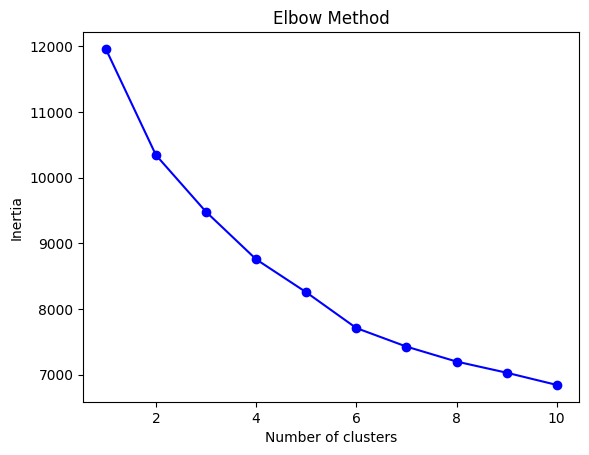

In [ ]:
# Elbow method to choose number of clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(features_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.plot(K, inertia, "bo-")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
# KMeans clustering
# Since target has 5 heart disease classes, we use 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(features_scaled)

cluster_labels = kmeans.labels_
sil_score = silhouette_score(features_scaled, cluster_labels)
print("KMeans Silhouette Score:", sil_score)

KMeans Silhouette Score: 0.14391016135964532


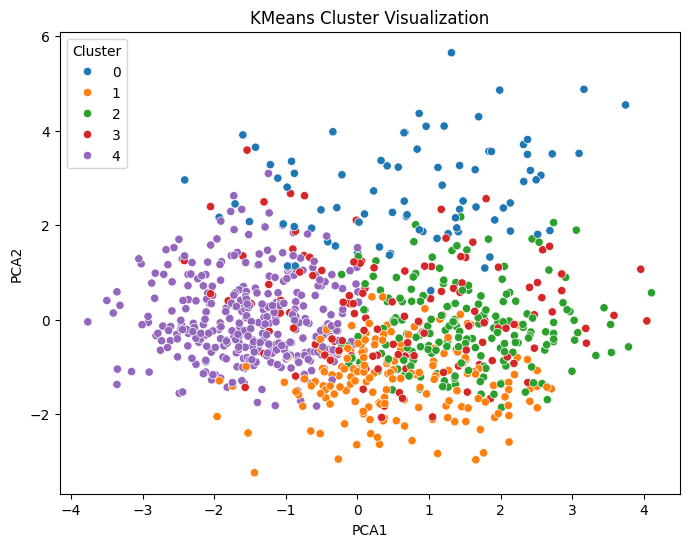

In [ ]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

cluster_df = pd.DataFrame({
    "PCA1": features_pca[:, 0],
    "PCA2": features_pca[:, 1],
    "Cluster": cluster_labels,
    "Actual Class": target
})

plt.figure(figsize=(8,6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=cluster_df, palette="tab10")
plt.title("KMeans Cluster Visualization")
plt.show()

## Model Selection / Comparison Analysis

In [ ]:
# Collecting results for bar chart
results = {
    "KNeighbours": {"Accuracy": accuracy_KNeighbours, "Precision": precision_KNeighbours, "Recall": recall_KNeighbours, "F1": f1_KNeighbours},
    "Decision Tree": {"Accuracy": accuracy_DT, "Precision": precision_DT, "Recall": recall_DT, "F1": f1_DT},
    "Logistic Regression": {"Accuracy": accuracy_LR, "Precision": precision_LR, "Recall": recall_LR, "F1": f1_LR},
    "Naive Bayes": {"Accuracy": accuracy_NB, "Precision": precision_NB, "Recall": recall_NB, "F1": f1_NB},
    "Neural Network": {"Accuracy": accuracy_NN, "Precision": precision_NN, "Recall": recall_NN, "F1": f1_NN}
}

results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1
KNeighbours,0.583333,0.527530,0.583333,0.551788
Decision Tree,0.507246,0.512722,0.507246,0.509765
Logistic Regression,0.568841,0.535231,0.568841,0.549330
Naive Bayes,0.536232,0.536517,0.536232,0.535935
Neural Network,0.474638,0.486163,0.474638,0.479318


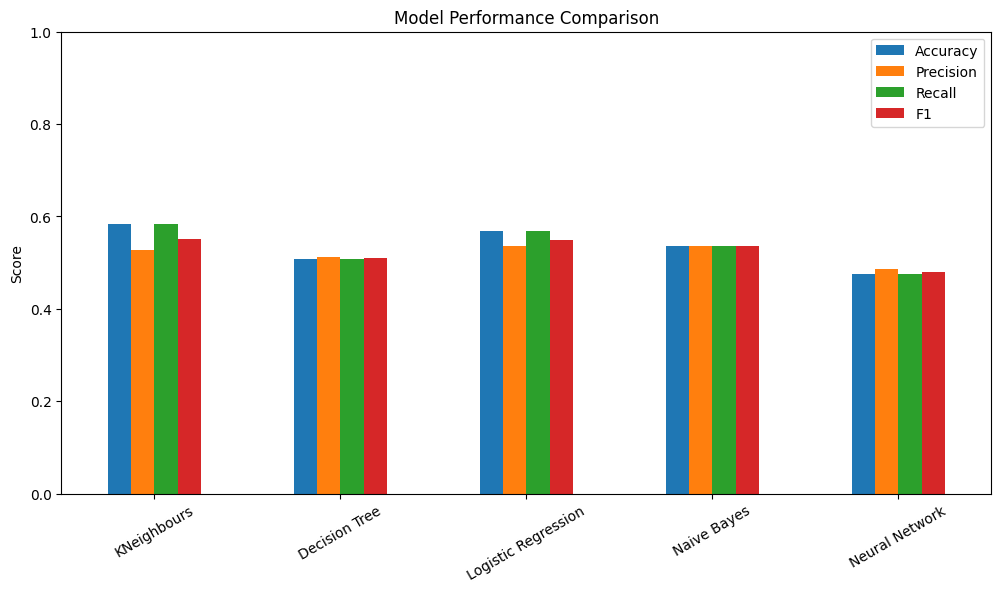

In [ ]:
# Bar chart for model performance
results_df.plot(kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

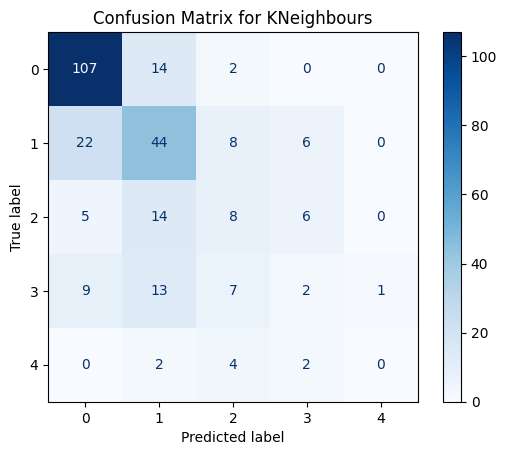

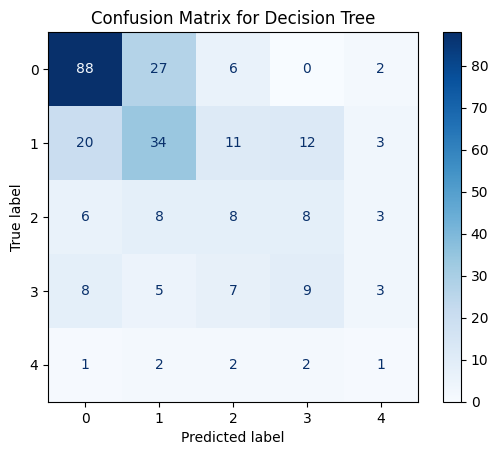

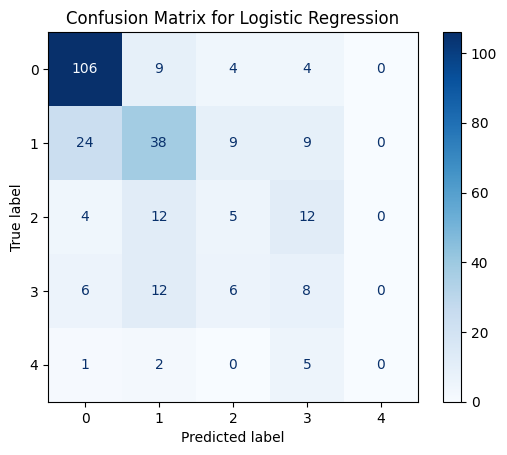

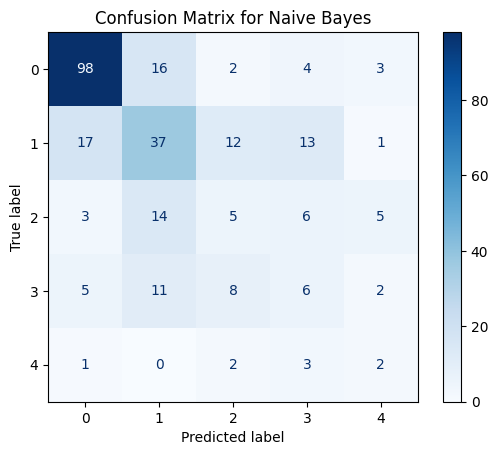

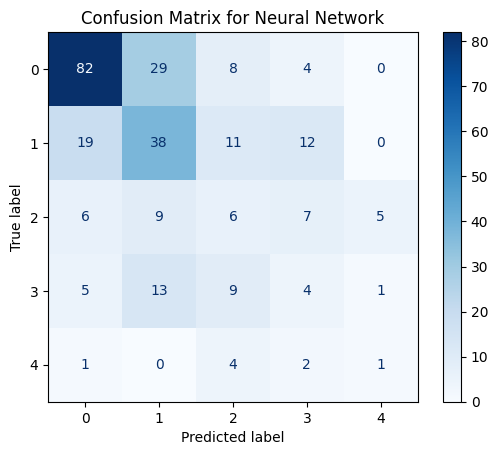

In [ ]:
# Confusion matrix
model_predictions = {
    "KNeighbours": (knn, target_pred_KNeighbours),
    "Decision Tree": (dT, target_pred_DT),
    "Logistic Regression": (lr, target_pred_LR),
    "Naive Bayes": (nb, target_pred_NB),
    "Neural Network": (mlp, target_pred_NN)
}

for name, (model, pred) in model_predictions.items():
    cm = confusion_matrix(target_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues", xticks_rotation=0)
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

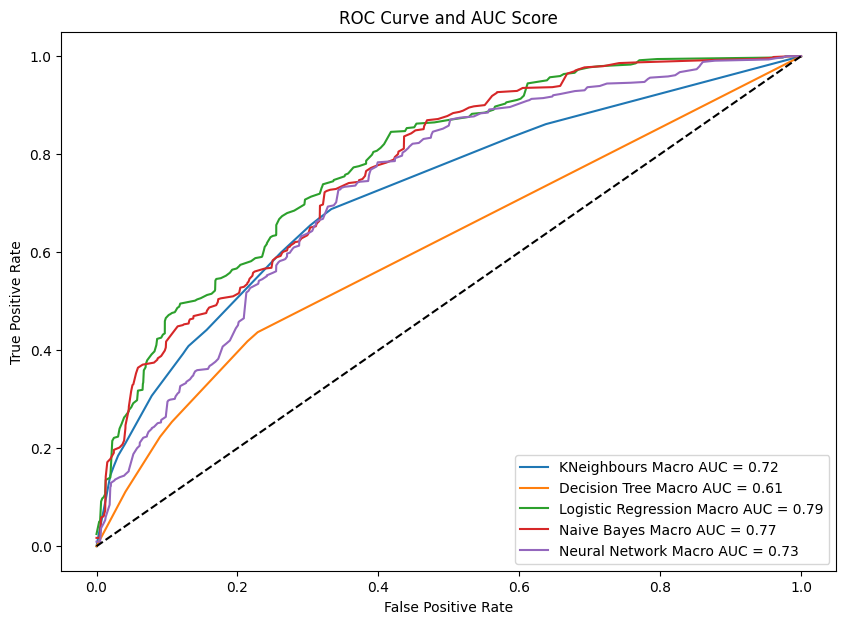

In [ ]:
# ROC curve and AUC score for multi-class classification
classes = np.unique(target)
target_test_bin = label_binarize(target_test, classes=classes)

plt.figure(figsize=(10, 7))

for name, (model, pred) in model_predictions.items():
    if hasattr(model, "predict_proba"):
        target_probs = model.predict_proba(features_test)
        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(len(classes)):
            fpr[i], tpr[i], _ = roc_curve(target_test_bin[:, i], target_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(len(classes)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

        mean_tpr /= len(classes)
        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, label=f"{name} Macro AUC = {macro_auc:.2f}")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve and AUC Score")
plt.legend()
plt.show()

## K-Fold Cross Validation

In [ ]:
# Stratified K-Fold Cross Validation
# better than train-test split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

kfold_models = {
    "KNeighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

kfold_scores = {}
for name, model in kfold_models.items():
    scores = cross_val_score(model, features_scaled, target, cv=skf, scoring="accuracy")
    kfold_scores[name] = scores.mean()
    print(name)
    print("Fold scores:", scores)
    print("Mean accuracy:", scores.mean())
    print()

kfold_df = pd.DataFrame.from_dict(kfold_scores, orient="index", columns=["Mean Accuracy"])
display(kfold_df)

KNeighbours
Fold scores: [0.55978261 0.57608696 0.54891304 0.55978261 0.55978261]
Mean accuracy: 0.5608695652173914

Decision Tree
Fold scores: [0.45652174 0.52173913 0.44565217 0.54891304 0.45652174]
Mean accuracy: 0.4858695652173912

Logistic Regression
Fold scores: [0.57065217 0.59782609 0.57608696 0.57608696 0.54347826]
Mean accuracy: 0.5728260869565217

Naive Bayes
Fold scores: [0.55434783 0.60869565 0.54891304 0.57608696 0.21195652]
Mean accuracy: 0.5

Neural Network
Fold scores: [0.51086957 0.55978261 0.47282609 0.55434783 0.52173913]
Mean accuracy: 0.5239130434782608



,Mean Accuracy
KNeighbours,0.560870
Decision Tree,0.485870
Logistic Regression,0.572826
Naive Bayes,0.500000
Neural Network,0.523913


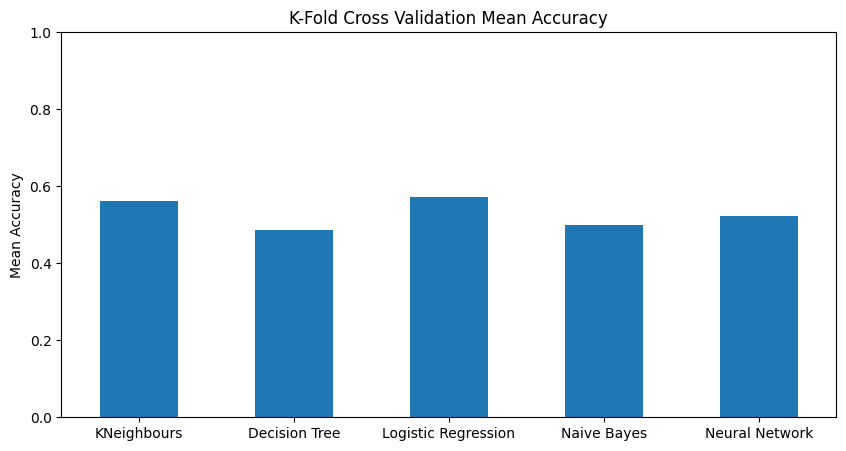

In [ ]:
# K-Fold accuracy bar chart
kfold_df.plot(kind="bar", figsize=(10,5), legend=False)
plt.title("K-Fold Cross Validation Mean Accuracy")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

## Best Model

In [ ]:
best_model = results_df["Accuracy"].idxmax()
best_accuracy = results_df.loc[best_model, "Accuracy"]

print("Best Model:", best_model)
print("Best Test Accuracy:", best_accuracy)

Best Model: KNeighbours
Best Test Accuracy: 0.5833333333333334
